## 1. Load and Inspect Dataset
Collect a labeled dataset of news articles.
Clean and preprocess the text data by removing noise (e.g., punctuation, stopwords).
Handle missing data if present.
Ensure the data is ready for feature extraction.

In [11]:
import pandas as pd
import numpy as np
import re
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Load the dataset
# Assuming the dataset is in CSV format
df = pd.read_csv("data_news.csv")
# Display data structure
df.head()

,category,headline,links,short_description,keywords
0,BUSINESS,A Magician of Time,https://www.huffingtonpost.com/entry/time-mana...,"I don't have time for everything I want to do,...",time-management
1,BUSINESS,Here's A Full List Of The Beef Products Recall...,https://www.huffingtonpost.com/entry/beef-reca...,Nearly 9 million pounds of beef produced by th...,beef-recall
2,BUSINESS,How Do Innovators Create New Markets?,https://www.huffingtonpost.com/entry/post_8726...,"How do innovators transform new machines, mole...",post
3,BUSINESS,How Do Innovators Create New Markets?,https://www.huffingtonpost.com/entry/post_8726...,"How do innovators transform new machines, mole...",post
4,BUSINESS,Hunt a Mammoth,https://www.huffingtonpost.com/entry/post_7768...,Unplug and reconnect. Amazing how the message ...,post


## 2. Data Preprocessing
Convert text data into numerical features using TF-IDF.
Perform EDA to understand category distribution.

In [7]:

#Check for missing values
print(df.isnull().sum())
df = df.dropna()  # Drop rows with missing values

# Preprocess the text data
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Remove special characters and digits
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert to lowercase
    text = text.lower()
    # Remove stopwords
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

df['cleaned_text'] = df['category'].apply(preprocess_text)
# Encode target labels (categories) into numerical form
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['category_encoded'], test_size=0.2, random_state=42)

NameError: name 'df' is not defined

## 3. Feature Extraction
Train models using Logistic Regression, Naive Bayes, and SVM.
Perform hyperparameter tuning and cross-validation.

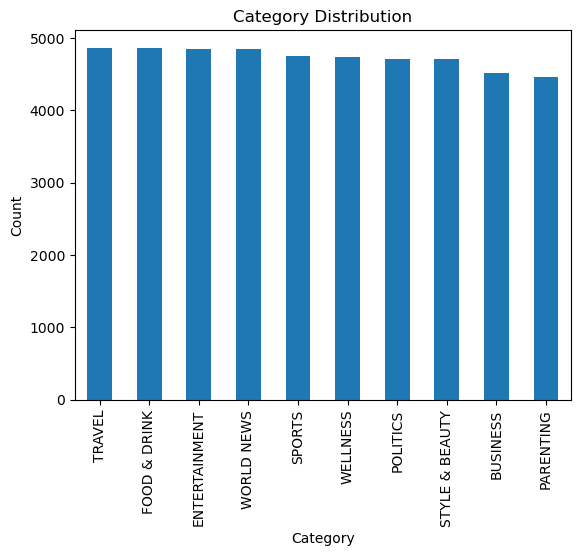

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Exploratory Data Analysis (EDA)
category_counts = df['category'].value_counts()
category_counts.plot(kind='bar', title="Category Distribution")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


## 4. Model Training
Use accuracy, precision, recall, and F1-score to evaluate models.
Compare performance and select the best model.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)
log_reg_scores = cross_val_score(log_reg, X_train_tfidf, y_train, cv=5)

# Naive Bayes
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_tfidf, y_train)
nb_scores = cross_val_score(naive_bayes, X_train_tfidf, y_train, cv=5)

# SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
svm_scores = cross_val_score(svm_model, X_train_tfidf, y_train, cv=5)

print(f"Logistic Regression Average CV Score: {np.mean(log_reg_scores):.4f}")
print(f"Naive Bayes Average CV Score: {np.mean(nb_scores):.4f}")
print(f"SVM Average CV Score: {np.mean(svm_scores):.4f}")


Logistic Regression Average CV Score: 0.7848
Naive Bayes Average CV Score: 0.7762
SVM Average CV Score: 0.7765


## 5. Final Report
Visualize performance metrics and important features.

Index(['category', 'headline', 'links', 'short_description', 'keywords',
       'cleaned_text'],
      dtype='object')
Index(['category', 'headline', 'links', 'short_description', 'keywords',
       'cleaned_text'],
      dtype='object')


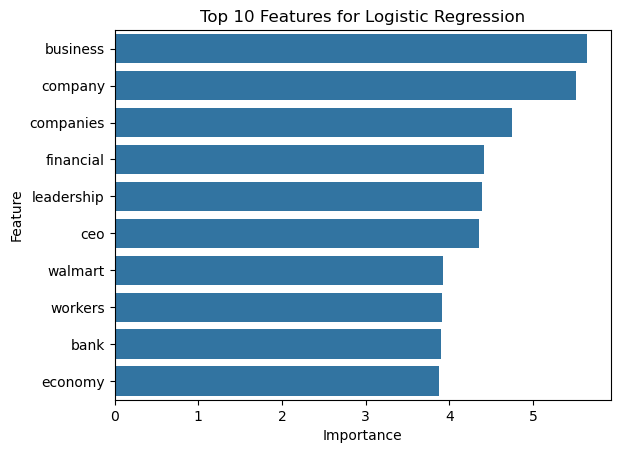

In [21]:
print(df.columns)
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# Check available columns
print(df.columns)

# Assuming 'short_description' contains the text data
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

# Create 'cleaned_text' column by preprocessing the text data
df['cleaned_text'] = df['short_description'].apply(preprocess_text)
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
# Initialize the model
lr_model = LogisticRegression()
from sklearn.model_selection import train_test_split

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['category'], test_size=0.2, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Assuming `lr_model` is your trained Logistic Regression model
feature_importances = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': lr_model.coef_[0]
}).sort_values(by='importance', ascending=False).head(10)

sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title("Top 10 Features for Logistic Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


video explanation:
### https://drive.google.com/file/d/1SEznm4ms5e_24cMFikQ2Xpl-eUFDiIDq/view?usp=sharing